# 5. The full inference, start to finish

This notebook **is** `scripts/run_union21.py`. It imports that script
and calls its functions in order, so the numbers and the figures here are
literally the ones written to `results/`.

The steps:

1. Load Union2.1 and build the posterior;
2. Warm up, then **freeze** the proposal;
3. Decide **how long** the chains have to be;
4. Run dispersed chains;
5. Report the constraints and check convergence;
6. Cross-check the analytic marginalization.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPOSITORY = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPOSITORY / "scripts"))

import run_union21 as pipeline

pipeline._style()    
SEED = 20260908
rng = np.random.default_rng(SEED)

print("using", pipeline.__file__)

using /Users/hugodiniz/Documents/Projects/T1aSuper/scripts/run_union21.py


## 1. Data and posterior

The likelihood marginalizes the zero point $\mathcal{M}$ analytically, so the
sampled space is two-dimensional. The prior is the flat box
$0 \le \Omega_m \le 2$ and $-1 \le \Omega_\Lambda \le 3$.

In [2]:
from snia.data.union21 import load_union21
from snia.data.likelihood import Union21Likelihood
from snia.bayes.posterior import Posterior, UniformPrior
from snia.bayes.proposals import GaussianRandomWalk
from snia.bayes.samplers import run_chains

z, mu, cov = load_union21(systematics=True)
sigma = np.sqrt(np.diag(cov))

likelihood = Union21Likelihood(z, mu, cov)
posterior = Posterior(
    likelihood.log_likelihood,
    UniformPrior(pipeline.PRIOR_LOWER, pipeline.PRIOR_UPPER),
)

print(f"{z.size} supernovae, z from {z.min():.3f} to {z.max():.3f}")
print(f"log posterior at (0.3, 0.7) = {posterior([0.3, 0.7]):.3f}")

580 supernovae, z from 0.015 to 1.414
log posterior at (0.3, 0.7) = -272.561


## 2. Warm up and freeze

A pilot chain with a crude diagonal proposal learns the *shape* of the
posterior. That covariance is then frozen: adapting while collecting samples
would break the Markov property and invalidate the chain.

In [3]:
tuned, centre, pilot_acceptance = pipeline.tune_proposal(posterior, 8000, rng)
proposal = GaussianRandomWalk(tuned, scale=pipeline.OPTIMAL_SCALE)

eigenvalues, eigenvectors = np.linalg.eigh(tuned)
print(f"pilot acceptance {pilot_acceptance:.3f}")
print("tuned covariance, now frozen:")
for row in tuned:
    print("   " + "  ".join(f"{value: .6f}" for value in row))
print(f"\ndegeneracy {np.sqrt(eigenvalues[1] / eigenvalues[0]):.1f} : 1"
      f"  along {eigenvectors[:, 1].round(2)}")

pilot acceptance 0.669
tuned covariance, now frozen:
    0.013482   0.021078
    0.021078   0.046340

degeneracy 4.2 : 1  along [0.44 0.9 ]


## 3. How many steps do the chains need?

In [4]:
recommended, tau_probe = pipeline.calibrate_length(
    posterior, proposal, centre, rng, target_r=0.01
)
print(f"tau_int on the calibration run : {tau_probe:.2f}")
for target in (0.01, 0.001):
    print(f"  N for r < {target:<6g} -> {int(np.ceil(tau_probe / target)):>8,} steps"
          f"   (MCSE = {100 * np.sqrt(target):.0f}% of the posterior width)")

tau_int on the calibration run : 7.25
  N for r < 0.01   ->      725 steps   (MCSE = 10% of the posterior width)
  N for r < 0.001  ->    7,248 steps   (MCSE = 3% of the posterior width)


In [ ]:
from snia.bayes.samplers import MetropolisHastings
from snia.diagnostics.spectral import fit_dunkley

long_chain = MetropolisHastings(posterior, proposal).sample(
    centre, 60000, np.random.default_rng(1)
)

print(f"{'N':>8} {'r fitted':>10} {'tau/N':>10}")
for n in (500, 1000, 2000, 5000, 10000, 20000, 40000, 60000):
    r = fit_dunkley(long_chain.samples[:n, 0]).r
    print(f"{n:8,} {r:10.5f} {tau_probe / n:10.5f}")

print(f"\nr first drops below 0.01 at N = 2,000;"
      f" the rule predicts {int(np.ceil(tau_probe / 0.01)):,}")

       N   r fitted      tau/N
     500    0.02432    0.01449
   1,000    0.00772    0.00725
   2,000    0.00421    0.00362
   5,000    0.00160    0.00145
  10,000    0.00079    0.00072
  20,000    0.00041    0.00036
  40,000    0.00021    0.00018


  60,000    0.00014    0.00012

r first drops below 0.01 at N = 2,000; the rule predicts 725


## 4. Dispersed chains

Chains that begin far apart and end up agreeing are much stronger evidence than
one stable-looking trace. These start at $3\sigma$ from the pilot.

In [6]:
N_STEPS, N_CHAINS, BURN = 80000, 5, 8000

starts = pipeline.dispersed_starts(posterior, centre, tuned, N_CHAINS, rng)
production = run_chains(posterior, proposal, starts, N_STEPS, rng)
retained = production.burned(BURN)
samples = retained.samples

print("starting points:")
for start in starts:
    print("   " + "  ".join(f"{value: .4f}" for value in start))
print(f"\n{N_CHAINS} x {N_STEPS:,} steps, discarding {BURN:,} as burn-in")
print(f"burn-in is {BURN / tau_probe:.0f} correlation times, far more than needed")
print(f"{posterior.n_calls:,} posterior evaluations")

starting points:
    0.4224   1.2689
    0.0965   0.5881
    0.1682  -0.4171
    0.7542   1.3175
    0.1747   0.1249

5 x 80,000 steps, discarding 8,000 as burn-in
burn-in is 1104 correlation times, far more than needed
474,022 posterior evaluations


## 5. The constraints

`summarize` is the script's own reporting function.

In [7]:
pipeline.summarize(samples, likelihood, print)


--------------------------------------------------------------------------
CONSTRAINTS
--------------------------------------------------------------------------
parameter           mean       sd       16%       50%       84%
Omega_m           0.2814   0.1124    0.1651    0.2836    0.3947
Omega_Lambda      0.6613   0.2098    0.4474    0.6694    0.8728
Omega_k           0.0573   0.3103   -0.2556    0.0463    0.3775
q0               -0.5206   0.1655   -0.6868   -0.5273   -0.3535

accelerating (q0 < 0)          : 99.88% of the posterior
consistent with flat (|Ok|<.05): 12.38%
chi2 at the mean               : 545.15 for 580 SNe, chi2/dof = 0.9448
delta chi2 vs Einstein-de Sitter: 128.2
fitted zero point M            : 43.1738 mag -> H0 = 69.51


## 6. Convergence

In [8]:
converged = pipeline.report_convergence(
    samples, production.acceptance_rate, 0.01, print
)
print(f"\nall diagnostics passed: {converged}")


--------------------------------------------------------------------------
CONVERGENCE
--------------------------------------------------------------------------
acceptance per chain: [0.352 0.353 0.353 0.348 0.348]   (0.2-0.5 is healthy for a 2-D random walk)

parameter       tau_int      ESS      MCSE   MCSE/sd     Rhat  rank-Rhat
Omega_m            7.32    49191   0.00051    0.0045   1.0001     1.0001
Omega_Lambda       7.40    48641   0.00095    0.0045   1.0001     1.0002

  tau_int   steps before a sample is effectively independent
  ESS       independent-equivalent draws, pooled over all chains
  MCSE/sd   error on the mean as a fraction of the posterior width
  rank-Rhat between-chain agreement; must be < 1.01

Dunkley spectrum, per chain and parameter (unthinned):
parameter       chain        j*         r   alpha   verdict
Omega_m             0    2691.1   0.00011    1.74   PASS


Omega_m             1    2522.5   0.00012    1.71   PASS
Omega_m             2    2921.6   0.00011    1.84   PASS


Omega_m             3    2815.7   0.00011    1.77   PASS
Omega_m             4    2965.1   0.00011    1.84   PASS


Omega_Lambda        0    2513.8   0.00012    1.70   PASS
Omega_Lambda        1    2782.9   0.00011    1.82   PASS


Omega_Lambda        2    2929.5   0.00011    1.84   PASS
Omega_Lambda        3    2843.1   0.00011    1.79   PASS


Omega_Lambda        4    2604.1   0.00011    1.72   PASS

  thresholds: j* > 20 (white plateau resolved), r < 0.01 (mean precise)

Was the run long enough?
  measured tau_int (worst parameter) : 7.40
  N needed per chain for r < 0.01   : 741
  N actually used per chain          : 72,000  (97.2x)

rank-normalized Rhat < 1.01  : True
Dunkley thresholds passed  : True

all diagnostics passed: True


## 7. The figures

The same five figures the script writes to `results/`, produced by the same
functions.

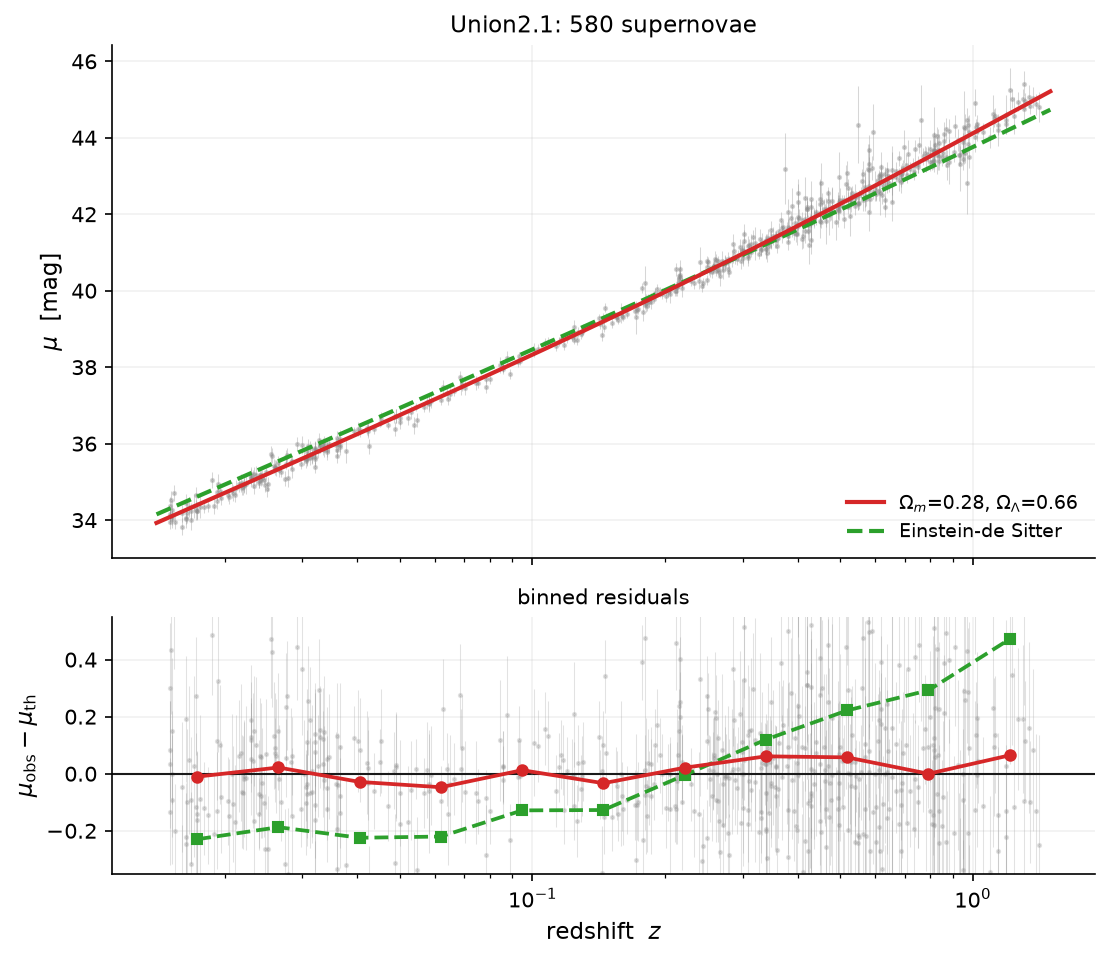

In [9]:
pipeline.figure_hubble(samples, likelihood, z, mu, sigma)
plt.show()

With its own best zero point, Einstein-de Sitter still drifts systematically
with redshift in the residual panel. That trend *is* the detection of
acceleration.

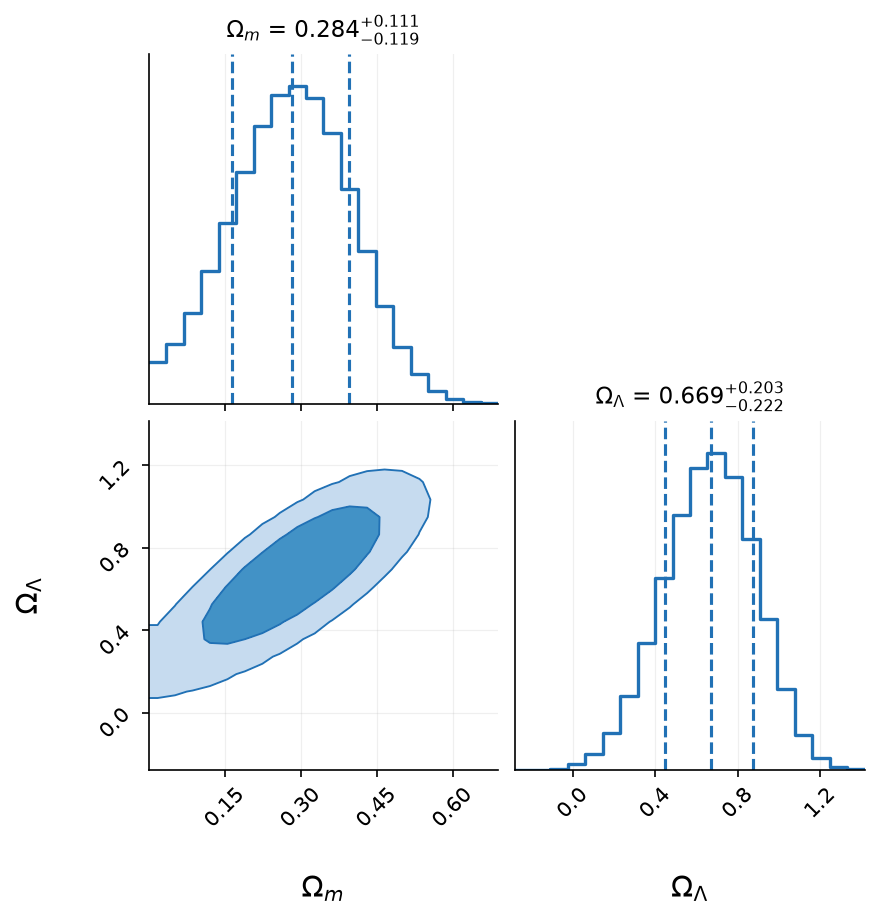

In [10]:
pipeline.figure_contours(samples)
plt.show()

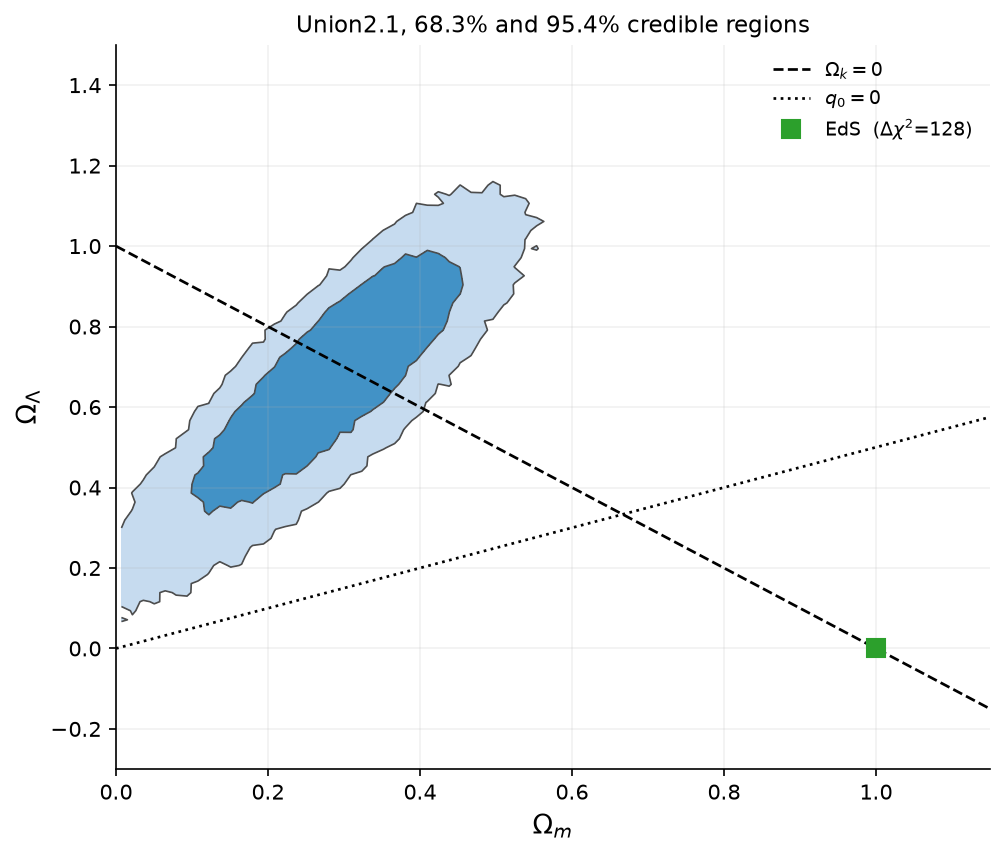

In [11]:
pipeline.figure_parameter_space(samples, likelihood)
plt.show()

The corner plot auto-scales to the posterior, which puts Einstein-de Sitter
off the edge; the second figure fixes the range so the comparison is visible.

The flat line runs straight through the allowed region: the data are consistent
with $\Omega_k = 0$ **without** it having been assumed. The contours are a long
narrow ellipse because supernovae constrain the combination
$q_0 = \Omega_m/2 - \Omega_\Lambda$ far better than either parameter alone —
which is why they are combined with the CMB or BAO, that cut the degeneracy at
a different angle.

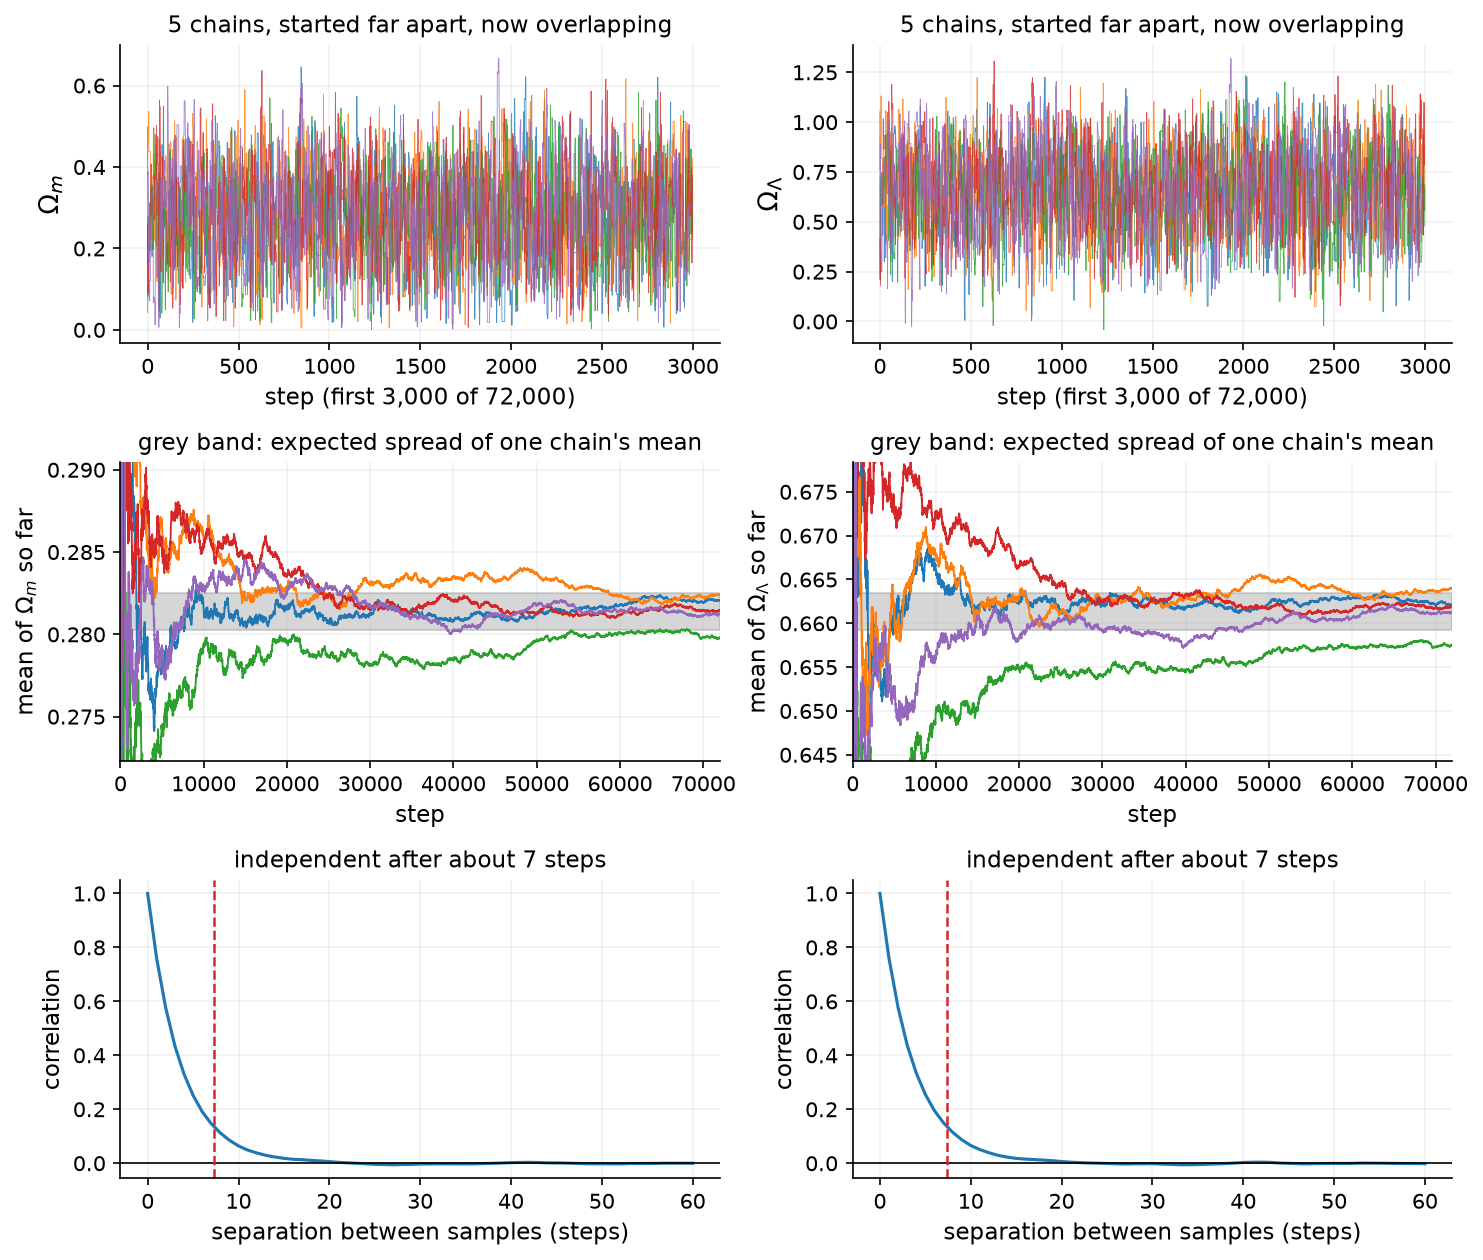

In [12]:
pipeline.figure_convergence(samples)
plt.show()

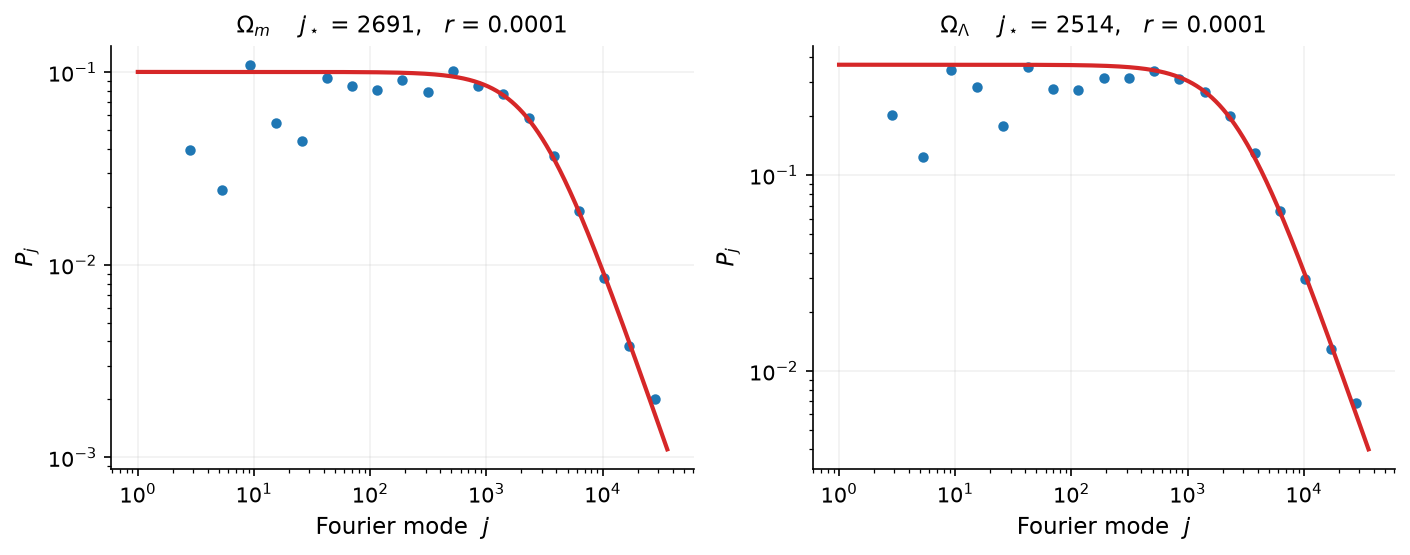

In [13]:
pipeline.figure_dunkley(samples)
plt.show()

## 8. Cross-check: sample $\mathcal{M}$ instead of marginalizing it

The analytic $\chi^2 = A - B^2/E$ assumes a flat prior on $\mathcal{M}$.
Sampling it as a third parameter must give the same $(\Omega_m, \Omega_\Lambda)$.
A sign error in $B$ would show up here and nowhere else.

In [14]:
pipeline.cross_check(
    likelihood, tuned, N_STEPS, rng,
    samples.reshape(-1, samples.shape[-1]), print,
)


--------------------------------------------------------------------------
CROSS-CHECK: M sampled instead of marginalized analytically
--------------------------------------------------------------------------
parameter                   analytic             M sampled     agreement
Omega_m           0.2814 +- 0.1124    0.2809 +- 0.1124     0.57 MCSE
Omega_Lambda      0.6613 +- 0.2098    0.6611 +- 0.2099     0.14 MCSE
M                 (marginalized out)   43.1732 +- 0.0326

A sign error in B, or a swapped residual convention, would separate
these. Nothing else in the pipeline would notice.
